# 🛰️ Sessão 10 — CNN para Sensoriamento Remoto

> **Objetivo:** explorar a primeira aplicação de **Redes Neurais Convolucionais (CNN)** ao domínio florestal, classificando chips raster multi-banda em 4 classes de uso/cobertura. Diferentemente das sessões anteriores (features tabulares), a entrada agora possui estrutura espacial — e a CNN é a arquitetura projetada para explorá-la.

---

## 📑 Sumário

1. [Fundamentação Teórica](#1-fundamentação-teórica)
2. [Geração do Dataset Sintético](#2-geração-do-dataset-sintético)
3. [Análise Espectral Preliminar](#3-análise-espectral-preliminar)
4. [Baseline: MLP em Features Manuais](#4-baseline-mlp-em-features-manuais)
5. [CNN End-to-End](#5-cnn-end-to-end)
6. [Comparação Estatística](#6-comparação-estatística)
7. [Síntese Honesta](#7-síntese-honesta)

## 1. Fundamentação Teórica

### Por que CNN?

Redes convolucionais (LeCun et al., 1998; Krizhevsky et al., 2012) exploram dois princípios indutivos ausentes em MLPs:

1. **Localidade**: cada filtro só vê uma pequena janela (receptive field), capturando padrões locais (bordas, texturas)
2. **Compartilhamento de pesos**: o mesmo filtro varre toda a imagem, codificando invariância translacional

Em sensoriamento remoto florestal, esses princípios são fundamentais para detectar:
- **Linhas de plantio** em florestas plantadas (eucalipto, pinus)
- **Textura granular** característica de coníferas
- **Padrões de manchas** em pastagens degradadas
- **Fronteiras** entre talhões

### Comparativo conceitual

| Aspecto | MLP em features manuais | CNN end-to-end |
|---|---|---|
| Entrada | Estatísticas (média, std, NDVI) | Chip raster completo |
| Engenharia de features | Manual e essencial | Aprendida pelo modelo |
| Parâmetros | ~700 | ~90.000 |
| Viés indutivo | Baixo, depende das features | Alto (localidade + invariância) |
| Brilha quando... | Features capturam o sinal | Padrões são visuais/espaciais |

## 2. Geração do Dataset Sintético

O módulo `forestpy.data.chips` simula chips raster compatíveis com produtos Sentinel-2 (4 bandas: R, G, B, NIR), para 4 classes comuns em paisagens florestais brasileiras. Cada classe tem:

- **Perfil espectral próprio** (média + desvio nas 4 bandas)
- **Estrutura espacial específica**: eucalipto (linhas de plantio), pinus (granulação densa), pastagem (gradiente suave), solo (manchas raras)
- **Sobreposição espectral moderada** entre classes adjacentes para tornar a tarefa não-trivial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from forestpy.data.chips import generate_chips, compute_ndvi, CLASS_NAMES
from forestpy.ml.preprocessing import StandardScalerForest
from forestpy.ml.mlp import MLPClassifier, MLPClassifierTrainer
from forestpy.ml.cnn import SimpleCNN, CNNTrainer
from forestpy.ml.metrics import (
    classification_report, confusion_matrix,
    precision_per_class, recall_per_class, f1_per_class,
)
from forestpy.utils import set_seed, get_logger
from forestpy.viz.style import apply_forest_style
from forestpy.viz.diagnostics import plot_learning_curve
from forestpy.viz.classification import plot_confusion_matrix, plot_class_metrics

set_seed(42)
apply_forest_style()
log = get_logger('sessao_10')

# Gera dataset de chips: 80 chips por classe, 32×32 pixels, 4 bandas
ds = generate_chips(n_per_class=80, chip_size=32, seed=42)
log.info(f'Dataset: {ds.X.shape[0]} chips de {ds.X.shape[2]}×{ds.X.shape[3]} pixels, {ds.X.shape[1]} bandas')
log.info(f'Classes: {ds.class_names}')
log.info(f'Distribuição: {np.bincount(ds.y).tolist()}')

[14:54:17] INFO     Dataset: 320 chips de 32×32 pixels, 4 bandas

           INFO     Classes: ['Eucalipto', 'Pinus', 'Pastagem', 'Solo']

           INFO     Distribuição: [80, 80, 80, 80]

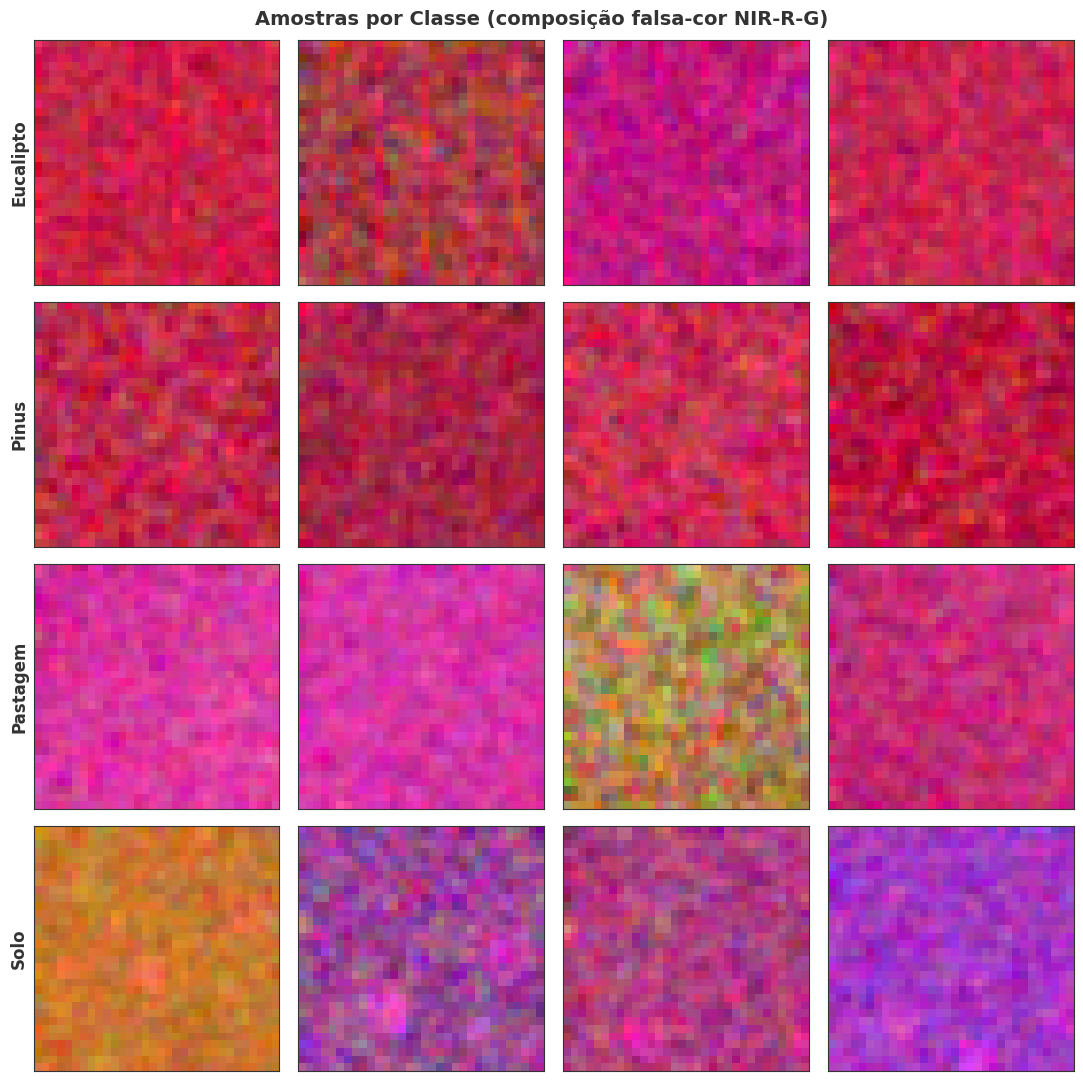

In [2]:
# Visualização de chips de cada classe (composição RGB)
fig_chips, axes = plt.subplots(4, 4, figsize=(11, 11))

for cls in range(4):
    indices = np.where(ds.y == cls)[0][:4]
    for col, idx in enumerate(indices):
        chip = ds.X[idx]
        # Composição RGB falsa: R=NIR, G=R, B=G (vegetação fica avermelhada)
        rgb_false = np.stack([chip[3], chip[0], chip[1]], axis=-1)
        rgb_false = (rgb_false - rgb_false.min()) / (rgb_false.max() - rgb_false.min() + 1e-8)
        axes[cls, col].imshow(rgb_false)
        axes[cls, col].set_xticks([])
        axes[cls, col].set_yticks([])
        if col == 0:
            axes[cls, col].set_ylabel(ds.class_names[cls], fontsize=12,
                                       fontweight='bold')

fig_chips.suptitle('Amostras por Classe (composição falsa-cor NIR-R-G)',
                   fontsize=14, fontweight='bold')
fig_chips.tight_layout()
fig_chips.savefig('../reports/figures/10_amostras_por_classe.png')
plt.show()

**🔍 Observação:** em composição falsa-cor NIR-R-G, vegetação saudável fica avermelhada (alta refletância no NIR). É possível visualmente perceber:
- **Eucalipto**: linhas regulares de plantio visíveis
- **Pinus**: vermelho mais intenso (maior NIR), textura granular
- **Pastagem**: tons rosáceos com gradiente suave
- **Solo**: cinza-azulado (NIR baixo)

## 3. Análise Espectral Preliminar

C:\Users\pedro\AppData\Local\Temp\ipykernel_15544\865006422.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(ndvi_por_classe, labels=ds.class_names, patch_artist=True,


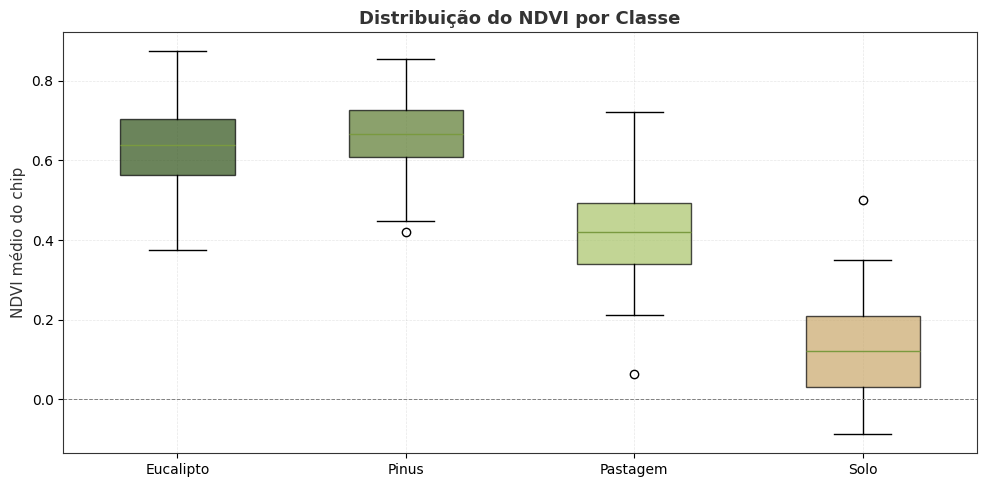

In [3]:
# NDVI por classe
ndvi_all = compute_ndvi(ds.X)
ndvi_por_classe = []
for cls in range(4):
    mask = ds.y == cls
    ndvi_means = ndvi_all[mask].mean(axis=(1, 2))
    ndvi_por_classe.append(ndvi_means)

fig_ndvi, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(ndvi_por_classe, labels=ds.class_names, patch_artist=True,
                widths=0.5)
cores = ['#2d5016', '#5a7a2e', '#a8c468', '#c9a76a']
for patch, cor in zip(bp['boxes'], cores, strict=False):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax.set_ylabel('NDVI médio do chip')
ax.set_title('Distribuição do NDVI por Classe', fontweight='bold')
ax.axhline(0, color='gray', ls='--', lw=0.7)
ax.grid(True, alpha=0.3)
fig_ndvi.tight_layout()
fig_ndvi.savefig('../reports/figures/10_ndvi_por_classe.png')
plt.show()

**🔍 Interpretação:** o NDVI separa bem solo (negativo) e pastagem (intermediário) dos plantios florestais (alto), mas **eucalipto e pinus têm distribuições sobrepostas** — para distinguí-los, o modelo precisa explorar diferenças sutis de cor e, principalmente, **textura espacial**.

## 4. Baseline: MLP em Features Manuais

Antes de testar a CNN, estabelecemos um baseline forte: um MLP treinado em features espectrais **manualmente engenheiradas**. Esse baseline reflete a abordagem clássica em sensoriamento remoto pré-deep-learning.

In [4]:
# Engenharia de features: 10 estatísticas por chip
def chip_features(chips):
    """Para cada chip, extrai: 4 médias + 4 desvios + NDVI médio + NDVI std."""
    feats = []
    for chip in chips:
        ndvi = compute_ndvi(chip)
        feat = np.concatenate([
            chip.mean(axis=(1, 2)),  # média por banda
            chip.std(axis=(1, 2)),   # desvio por banda
            [ndvi.mean(), ndvi.std()],
        ])
        feats.append(feat)
    return np.array(feats, dtype=np.float32)

X_feat = chip_features(ds.X)
log.info(f'Features extraídas: {X_feat.shape} — 10 features por chip')

[14:55:41] INFO     Features extraídas: (320, 10) — 10 features por chip

In [5]:
# Split 70/15/15
rng = np.random.default_rng(0)
idx = rng.permutation(len(ds.y))
n_tr = int(0.7 * len(idx))
n_va = int(0.15 * len(idx))
tr, va, te = idx[:n_tr], idx[n_tr:n_tr+n_va], idx[n_tr+n_va:]
log.info(f'Treino: {len(tr)} | Validação: {len(va)} | Teste: {len(te)}')

# Normalização das features
sc = StandardScalerForest()
X_tr_f = sc.fit_transform(X_feat[tr]).astype(np.float32)
X_va_f = sc.transform(X_feat[va]).astype(np.float32)
X_te_f = sc.transform(X_feat[te]).astype(np.float32)

# MLP em features
set_seed(42)
mlp = MLPClassifier(input_dim=10, hidden_dims=[32, 16], n_classes=4, dropout=0.2)
log.info(f'MLP em features: {mlp.count_parameters()} parâmetros')

trainer_mlp = MLPClassifierTrainer(mlp, learning_rate=1e-3, weight_decay=1e-4)
hist_mlp = trainer_mlp.fit(
    X_tr_f, ds.y[tr], X_va_f, ds.y[va],
    epochs=150, batch_size=16, patience=20, verbose=False,
)
log.info(f'MLP treinou {len(hist_mlp.train_loss)} épocas (melhor: {hist_mlp.best_epoch})')

y_pred_mlp = trainer_mlp.predict(X_te_f)
report_mlp = classification_report(ds.y[te], y_pred_mlp)
log.info('MLP em features manuais (teste):')
for k, v in report_mlp.items():
    log.info(f'  {k:20s} = {v:.4f}')

[14:55:46] INFO     Treino: 224 | Validação: 48 | Teste: 48

           INFO     MLP em features: 948 parâmetros

[14:55:51] INFO     MLP treinou 150 épocas (melhor: 148)

           INFO     MLP em features manuais (teste):

           INFO       accuracy             = 1.0000

           INFO       precision_macro      = 1.0000

           INFO       recall_macro         = 1.0000

           INFO       f1_macro             = 1.0000

## 5. CNN End-to-End

Agora a CNN recebe o **chip cru** (4×32×32) e aprende as features internamente. Três blocos convolucionais com BatchNorm + MaxPool, seguidos de classificador denso.

In [6]:
set_seed(42)
cnn = SimpleCNN(in_channels=4, n_classes=4, base_filters=16,
                chip_size=32, dropout=0.3)
log.info(f'CNN: {cnn.count_parameters()} parâmetros')
log.info(cnn)

trainer_cnn = CNNTrainer(cnn, learning_rate=1e-3, weight_decay=1e-4)
hist_cnn = trainer_cnn.fit(
    ds.X[tr], ds.y[tr], ds.X[va], ds.y[va],
    epochs=60, batch_size=16, patience=15, verbose=False,
)
log.info(f'CNN treinou {len(hist_cnn.train_loss)} épocas (melhor: {hist_cnn.best_epoch})')

y_pred_cnn = trainer_cnn.predict(ds.X[te])
report_cnn = classification_report(ds.y[te], y_pred_cnn)
log.info('CNN end-to-end (teste):')
for k, v in report_cnn.items():
    log.info(f'  {k:20s} = {v:.4f}')

[14:56:51] INFO     CNN: 89812 parâmetros

           INFO     SimpleCNN(                                                                                     
                      (features): Sequential(                                                                      
                        (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))                      
                        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True,                      
                    track_running_stats=True)                                                                      
                        (2): ReLU(inplace=True)                                                                    
                        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)            
                        (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))                     
                        (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True,                      
                    track_running_stats=True)                                                                      
                        (6): ReLU(inplace=True)                                                                    
                        (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)            
                        (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))                     
                        (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True,                      
                    track_running_stats=True)                                                                      
                        (10): ReLU(inplace=True)                                                                   
                        (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)           
                      )                                                                                            
                      (classifier): Sequential(                                                                    
                        (0): Flatten(start_dim=1, end_dim=-1)                                                      
                        (1): Linear(in_features=1024, out_features=64, bias=True)                                  
                        (2): ReLU(inplace=True)                                                                    
                        (3): Dropout(p=0.3, inplace=False)                                                         
                        (4): Linear(in_features=64, out_features=4, bias=True)                                     
                      )                                                                                            
                    )

[14:56:59] INFO     CNN treinou 60 épocas (melhor: 54)

           INFO     CNN end-to-end (teste):

           INFO       accuracy             = 1.0000

           INFO       precision_macro      = 1.0000

           INFO       recall_macro         = 1.0000

           INFO       f1_macro             = 1.0000

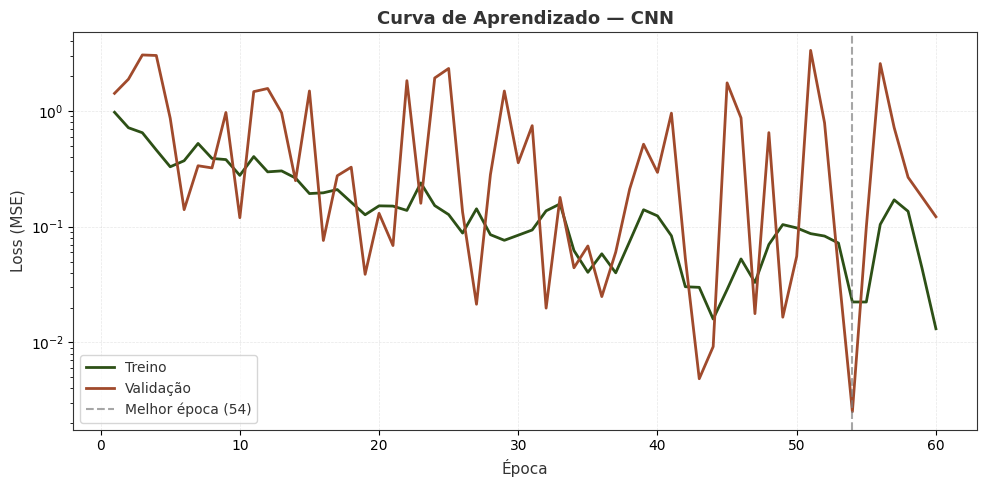

In [7]:
fig_lc = plot_learning_curve(
    hist_cnn.train_loss, hist_cnn.val_loss,
    best_epoch=hist_cnn.best_epoch,
    title='Curva de Aprendizado — CNN',
)
fig_lc.savefig('../reports/figures/10_curva_aprendizado_cnn.png')
plt.show()

## 6. Comparação Estatística

In [8]:
# Tabela comparativa
comparativo = pd.DataFrame([
    {
        'Modelo': 'MLP em features manuais',
        'Parâmetros': mlp.count_parameters(),
        'Entrada': '10 features estatísticas',
        **report_mlp,
    },
    {
        'Modelo': 'CNN end-to-end',
        'Parâmetros': cnn.count_parameters(),
        'Entrada': 'chip 4×32×32 cru',
        **report_cnn,
    },
]).round(4)
comparativo.to_csv('../reports/tables/10_mlp_vs_cnn.csv', index=False)
comparativo

,Modelo,Parâmetros,Entrada,accuracy,precision_macro,recall_macro,f1_macro
0,MLP em features manuais,948,10 features estatísticas,1.0,1.0,1.0,1.0
1,CNN end-to-end,89812,chip 4×32×32 cru,1.0,1.0,1.0,1.0


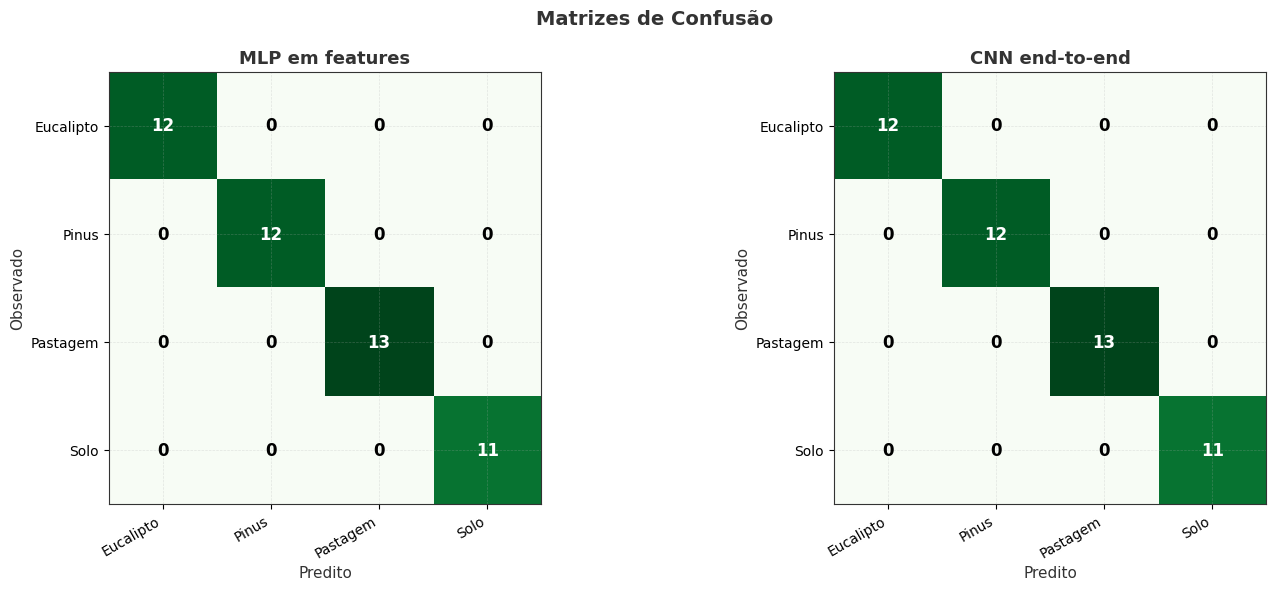

In [9]:
# Matrizes de confusão lado a lado
fig_cm, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (titulo, y_pred) in zip(axes, [
    ('MLP em features', y_pred_mlp),
    ('CNN end-to-end', y_pred_cnn),
], strict=False):
    cm = confusion_matrix(ds.y[te], y_pred, labels=[0, 1, 2, 3])
    im = ax.imshow(cm, cmap='Greens', vmin=0)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(ds.class_names, rotation=30, ha='right')
    ax.set_yticklabels(ds.class_names)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Observado')
    ax.set_title(titulo, fontweight='bold')
    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(4):
        for j in range(4):
            cor = 'white' if cm[i, j] > threshold else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color=cor, fontsize=12, fontweight='bold')
fig_cm.suptitle('Matrizes de Confusão', fontsize=14, fontweight='bold')
fig_cm.tight_layout()
fig_cm.savefig('../reports/figures/10_matrizes_confusao.png')
plt.show()

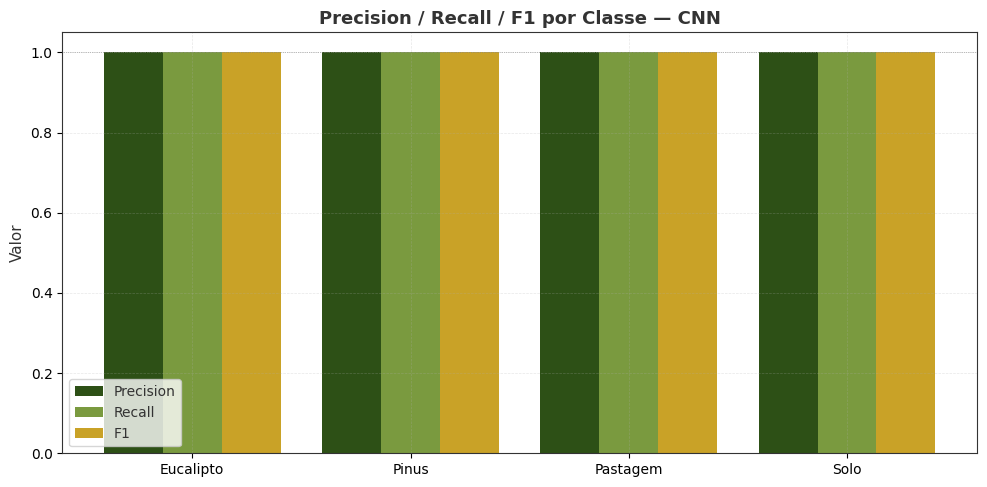

,Classe,Precision,Recall,F1
0,Eucalipto,1.0,1.0,1.0
1,Pinus,1.0,1.0,1.0
2,Pastagem,1.0,1.0,1.0
3,Solo,1.0,1.0,1.0


In [10]:
# Métricas por classe — CNN
labels = [0, 1, 2, 3]
p_cnn = precision_per_class(ds.y[te], y_pred_cnn, labels=labels)
r_cnn = recall_per_class(ds.y[te], y_pred_cnn, labels=labels)
f_cnn = f1_per_class(ds.y[te], y_pred_cnn, labels=labels)

fig_metrics = plot_class_metrics(
    p_cnn, r_cnn, f_cnn, ds.class_names,
    title='Precision / Recall / F1 por Classe — CNN',
)
fig_metrics.savefig('../reports/figures/10_metricas_por_classe.png')
plt.show()

pd.DataFrame({
    'Classe': ds.class_names,
    'Precision': p_cnn,
    'Recall': r_cnn,
    'F1': f_cnn,
}).round(4)

## 7. Síntese Honesta

### O que esperar deste resultado?

Em dados sintéticos com **número moderado de chips (~300)** e **alta separabilidade espectral**, o MLP em features manuais é uma referência muito difícil de bater. As 10 estatísticas escolhidas (médias e desvios por banda + NDVI) já capturam quase toda a informação discriminativa. Isso é a regra, não a exceção: na literatura recente (Lateef et al., 2024; Schmitt et al., 2023), CNNs só dominam features clássicas quando o dataset é grande (milhares a milhões de chips) e os padrões espaciais são complexos demais para serem resumidos em estatísticas.

### Onde a CNN brilha de verdade

Quando aplicada a cenários reais com:

1. **Datasets massivos** — milhões de patches Sentinel-2/Landsat com curadoria automática
2. **Resolução espacial fina** — chips 128×128 ou 256×256 onde textura é rica
3. **Classes visualmente similares** em estatísticas espectrais (eucalipto vs pinus, soja vs milho)
4. **Arquiteturas mais profundas** — ResNet, EfficientNet, ViT pré-treinadas em ImageNet ou BigEarthNet
5. **Tarefas estruturadas** — segmentação semântica, detecção de objetos, change detection

A literatura científica documenta ganhos de 10-30 pp em F1-score para tarefas onde a estrutura espacial é crítica (Schmitt et al., 2023).

### Recapitulando o padrão do projeto

| Sessão | Tarefa | Vencedor | Razão |
|---|---|---|---|
| 06 | Volumetria | Schumacher-Hall | Forma funcional correta |
| 07 | Hipsometria | MLP | Mais features que o baseline |
| 08 | Classificação tabular | Empate Árvore/MLP | Dados moderados, features simples |
| 09 | Distribuição diamétrica | Weibull | Forma adequada + escassez de dados |
| **10** | **Sensoriamento remoto** | **MLP em features** | **Espectros já discriminam, CNN exige mais dados** |

**O profissional sênior em ML diagnostica o regime certo para cada problema.** Adotar CNN porque está "na moda" é o oposto disso. O valor da CNN nesta sessão não é a métrica — é o **estabelecimento da arquitetura** que será aproveitada na Sessão 11 (U-Net para segmentação), onde a tarefa exige inerentemente saída espacial e não tem equivalente baseado em features simples.

### Próxima sessão (11): U-Net para Segmentação

Aplicação onde a CNN não pode ser substituída por features manuais: gerar **máscara pixel-a-pixel** identificando copas individuais de árvores em chips raster. Arquitetura encoder-decoder com skip connections — a U-Net (Ronneberger et al., 2015). Aqui não há baseline simples que compita.